## Day 5 - Baseline Prophet Model

##  Install and Import

In [3]:
!pip install mlflow
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

# Load prophet-ready data
df = pd.read_csv('../data/prophet_ready.csv', parse_dates=['ds'])
print(df.head())
print(f"Rows: {len(df)}")

  Using cached mlflow-3.13.0-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.13.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-3.0.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached databricks_sdk-0.114.0-py3-none-any.whl.metadata (43 kB)
  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached opentelemetry_api-1.42.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_proto-1.42.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached opentelemetry_sdk-1.42.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached sqlparse-0.5.5-py3-none-any.w

## Train-Test Split

In [5]:
# Use last 30 days as test set
split_date = df['ds'].max() - pd.Timedelta(days=30)

train = df[df['ds'] <= split_date]
test  = df[df['ds'] >  split_date]

print(f"Training rows: {len(train)}")
print(f"Testing rows:  {len(test)}")

Training rows: 709
Testing rows:  30


##  Build and Fit the Model

In [6]:
# Create model with weekly and yearly seasonality
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # better for retail (revenue grows over time)
    changepoint_prior_scale=0.05        # controls trend flexibility; 0.05 = default
)

model.fit(train)
print("Model trained!")

16:33:14 - cmdstanpy - INFO - Chain [1] start processing
16:33:15 - cmdstanpy - INFO - Chain [1] done processing


Model trained!


## Make Predictions

In [7]:
# Create future dataframe for next 30 days
future = model.make_future_dataframe(periods=30)

# Generate forecast
forecast = model.predict(future)

# Key columns in forecast:
# 'ds' = date
# 'yhat' = predicted value
# 'yhat_lower' = lower confidence bound
# 'yhat_upper' = upper confidence bound
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))

            ds          yhat    yhat_lower    yhat_upper
709 2011-11-10  50084.335453  35434.113913  64863.469749
710 2011-11-11  38074.353943  24557.157413  52300.422485
711 2011-11-12  12657.590024  -1258.343845  27178.446058
712 2011-11-13  31334.731544  16363.809105  44759.275849
713 2011-11-14  41385.260011  26379.193187  55831.566562
714 2011-11-15  47871.722053  34145.336263  61696.293188
715 2011-11-16  45473.761978  32581.924255  59776.852738
716 2011-11-17  54311.420450  39224.209883  67187.283914
717 2011-11-18  43009.677819  30143.849710  56353.443189
718 2011-11-19  18273.811461   3496.201006  32767.420803
719 2011-11-20  37663.761820  23129.248952  51797.196210
720 2011-11-21  48358.237797  34311.389680  62269.499423
721 2011-11-22  55402.179707  41088.450000  69294.830684
722 2011-11-23  53443.114920  38146.346376  67829.932144
723 2011-11-24  62606.855203  48265.104927  77438.252258
724 2011-11-25  51451.815078  37107.168272  66346.578783
725 2011-11-26  26674.243996  1

##  Evaluate with MAPE

In [9]:
import numpy as np
# Merge predictions with actual test values
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
test_merged = test.merge(test_forecast, on='ds')

# Calculate MAPE
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    # Avoid division by zero
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

mape_score = mape(test_merged['y'], test_merged['yhat'])
print(f"Prophet MAPE: {mape_score:.2f}%")
print(f"Target MAPE: ≤ 12%")
print("Passed" if mape_score <= 12 else "Need improvement")

Prophet MAPE: 35.72%
Target MAPE: ≤ 12%
Need improvement


## Visualize the Forecast

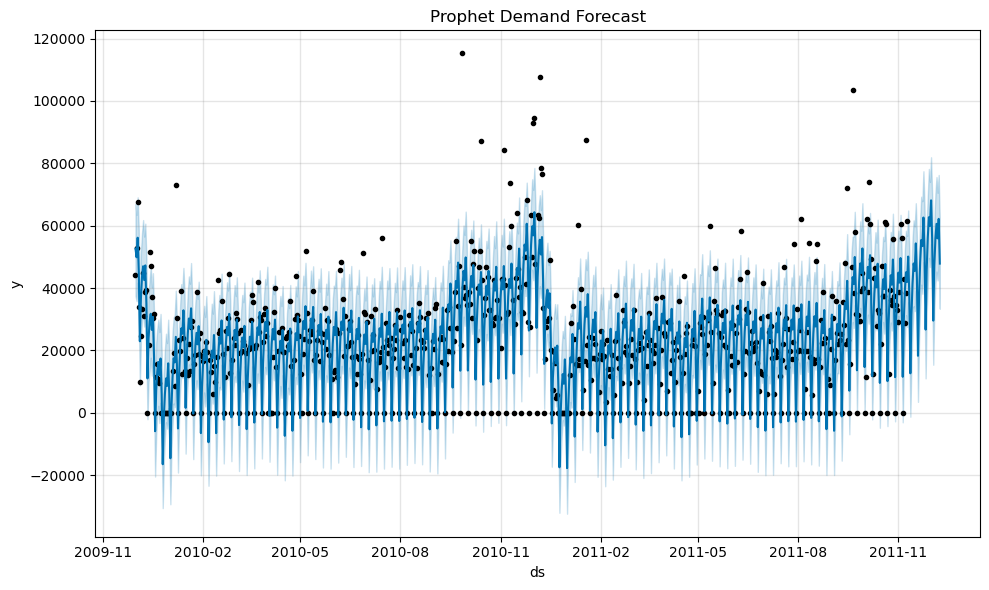

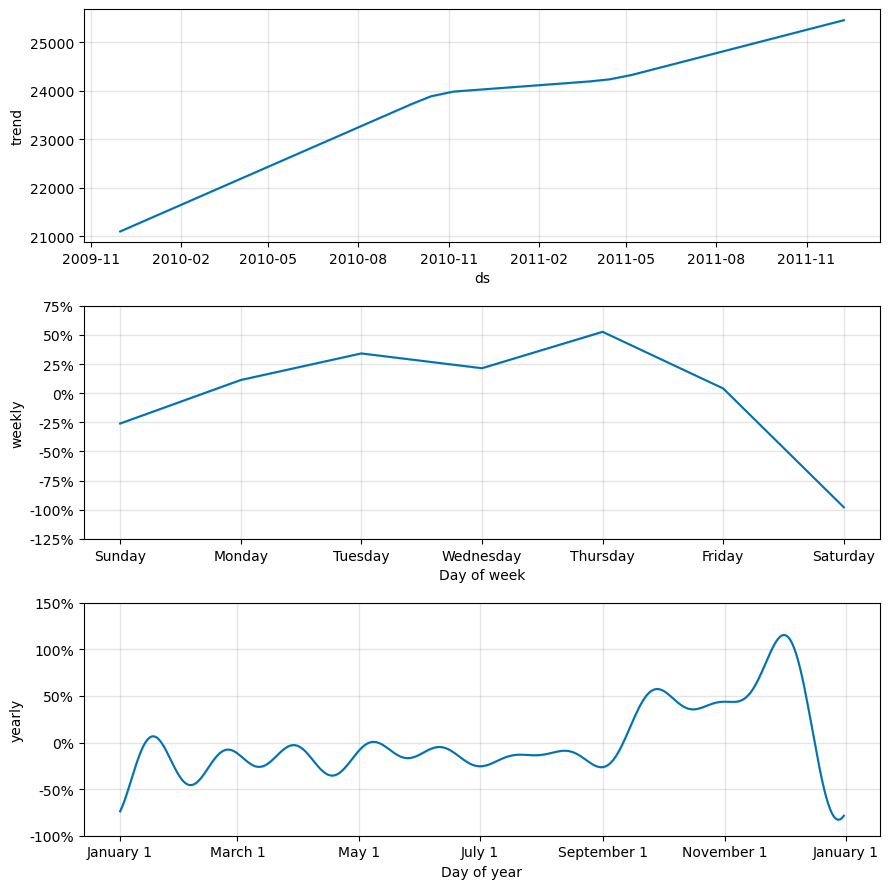

In [10]:
# Prophet's built-in plot
fig1 = model.plot(forecast)
plt.title('Prophet Demand Forecast')
plt.tight_layout()
plt.savefig('Day5_prophet_forecast.png')
plt.show()

# Component breakdown
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('Day5_prophet_components.png')
plt.show()
# This shows: overall trend + weekly pattern + yearly pattern separately

## Log to MLflow

In [15]:
# mlflow.set_experiment("RetailPulse_Forecasting")

# with mlflow.start_run(run_name="Prophet_Baseline"):
#     # Log parameters
#     mlflow.log_param("model_type", "Prophet")
#     mlflow.log_param("yearly_seasonality", True)
#     mlflow.log_param("weekly_seasonality", True)
#     mlflow.log_param("changepoint_prior_scale", 0.05)
    
    # # Log metrics
    # mlflow.log_metric("MAPE", mape_score)
    
    # Log artifacts (plots)
    # mlflow.log_artifact('Day5_prophet_forecast.png')
    
print(f"MLflow run logged. MAPE = {mape_score:.2f}%")

MLflow run logged. MAPE = 35.72%
